### Importing all the required modules 

In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Reading the CSV file and getting is detail 

In [171]:
data =pd.read_csv('studentPerformance.csv')
data.shape
data.info()



<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   student_id             20 non-null     str  
 1   gender                 20 non-null     str  
 2   attendance_percentage  20 non-null     int64
 3   study_hours_per_day    20 non-null     int64
 4   math_marks             20 non-null     int64
 5   science_marks          20 non-null     int64
 6   english_marks          20 non-null     int64
 7   parent_education       18 non-null     str  
 8   final_grade            20 non-null     str  
dtypes: int64(5), str(4)
memory usage: 1.5 KB


### filling na/null values with unknown in parent education

In [172]:
data["parent_education"] = data["parent_education"].fillna("Unknown")


### Visualizing Student Performance Data

#### 1. Average Marks per Subject
This bar chart displays the average marks achieved by students across three subjects: Math, Science, and English. It helps identify which subject students perform best in overall.

#### 2. Student Count by Final Grade
This visualization shows the distribution of students across different final grades (A, B, C, D, F), providing insight into the overall academic performance of the student population.

#### 3. Gender Distribution by Final Grade
This stacked bar chart illustrates how male and female students are distributed across different grade levels, revealing any gender-based performance patterns.

math_marks       67.30
science_marks    70.75
english_marks    70.20
dtype: float64


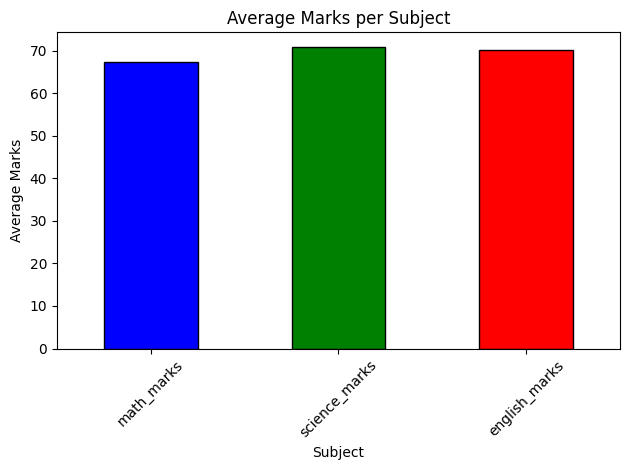


Number of students per grade:
final_grade
A    5
B    5
C    6
D    3
F    1
Name: count, dtype: int64


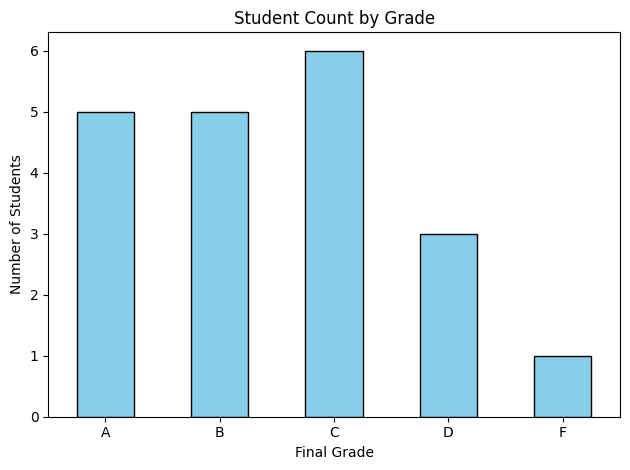

gender       Male  Female
final_grade              
A             0.0     5.0
B             1.0     4.0
C             5.0     1.0
D             3.0     0.0
F             1.0     0.0


Text(0.5, 1.0, 'Gender Distribution by Final Grade')

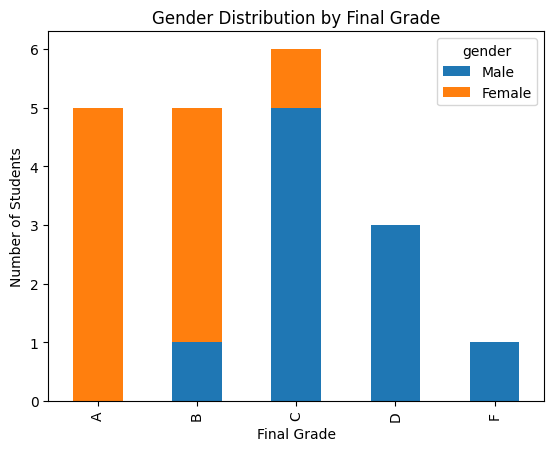

In [173]:
# Visualize average marks per subject
avgMarks = data[['math_marks', 'science_marks', 'english_marks']].mean()
print(avgMarks)
avgMarks.plot(kind='bar', color=['blue', 'green', 'red'], edgecolor='black')
plt.xlabel('Subject')
plt.ylabel('Average Marks')
plt.title('Average Marks per Subject')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualize student count per grade
grade_counts = data['final_grade'].value_counts().sort_index()
print("\nNumber of students per grade:")
print(grade_counts)
grade_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel('Final Grade')
plt.ylabel('Number of Students')
plt.title('Student Count by Grade')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Visualize gender performance
gender_perf = data[['final_grade', 'gender']].value_counts().unstack().sort_index().fillna(0)
print(gender_perf)
gender_perf.plot(kind='bar',stacked=True)
plt.xlabel('Final Grade')
plt.ylabel('Number of Students')
plt.title('Gender Distribution by Final Grade')


### Graph shows 
#### 1. relationship of student's per day studying time and their Final Grades
#### 2. relationship of student's parent education and their Final Grades
#### 3. relationship of student's attendance and their Final Grades


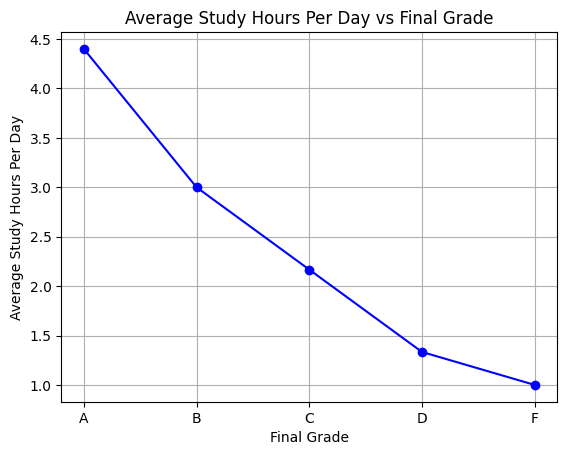

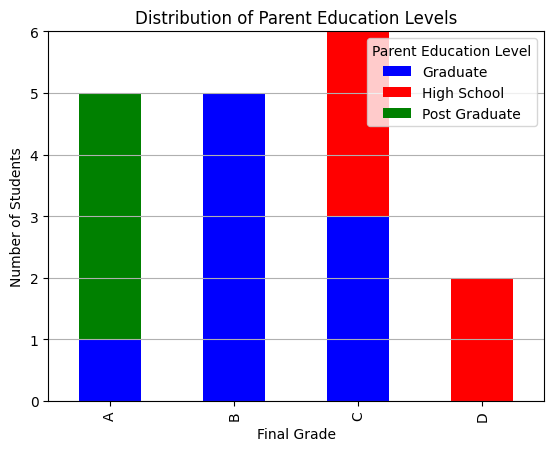

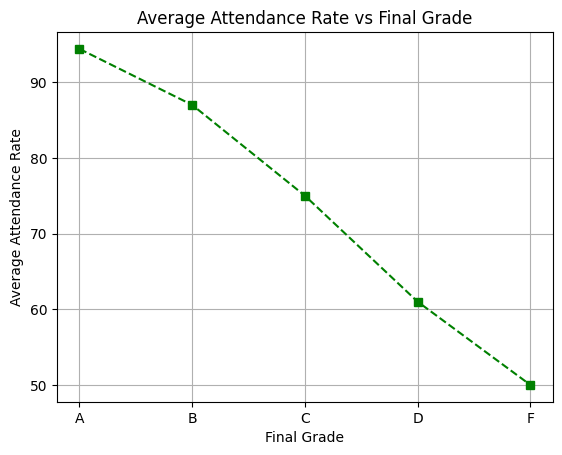

In [174]:
filterGrade =  data.groupby('final_grade')['study_hours_per_day'].mean()
plt.plot(filterGrade.index,filterGrade, marker='o', linestyle='-', color='b')
plt.grid()
plt.xlabel('Final Grade')
plt.ylabel('Average Study Hours Per Day')
plt.title('Average Study Hours Per Day vs Final Grade')
plt.show()

data2 = data[data['parent_education'] != 'Unknown']
filterEducation = data2.groupby('final_grade')['parent_education'].value_counts().unstack()
filterEducation.plot(kind='bar', stacked=True,color=['b','r','g','b'])
plt.legend(title='Parent Education Level')
plt.grid(axis='y')
plt.xlabel('Final Grade')
plt.ylabel('Number of Students')
plt.title('Distribution of Parent Education Levels')
plt.show()

attendance_vs_grade = data.groupby('final_grade')['attendance_percentage'].mean()
plt.plot(attendance_vs_grade.index, attendance_vs_grade, marker='s', linestyle='--', color='g')
plt.grid()
plt.xlabel('Final Grade')
plt.ylabel('Average Attendance Rate')
plt.title('Average Attendance Rate vs Final Grade')
plt.show()




   student_id  attendance_percentage final_grade
2        S003                     60           D
6        S007                     50           F
14       S015                     58           D


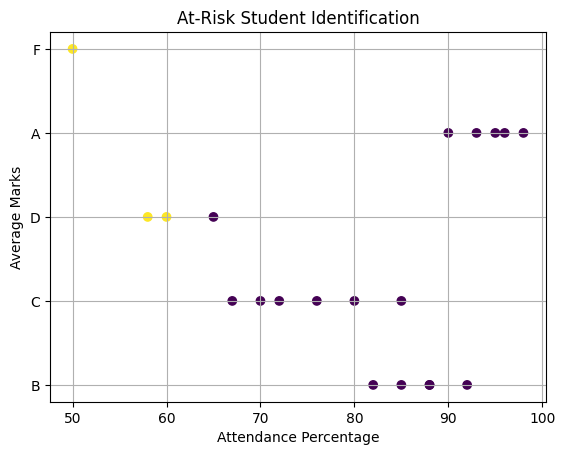


Summary of At-Risk Students:
Total at-risk students: 3

At-risk students by grade:
final_grade
D    2
F    1
Name: count, dtype: int64

Average attendance of at-risk students: 56.00%
Average marks of at-risk students: 42.56


In [181]:
avg = (data['math_marks'] + data['science_marks'] + data['english_marks'])/3
data['at_risk'] = (data["attendance_percentage"] <65) & (avg<50)
# print(data)
  
atRisk = data[data['at_risk']]
print(atRisk[['student_id','attendance_percentage','final_grade']])
# plt.scatter()
plt.scatter(data['attendance_percentage'], data['final_grade'], c=data['at_risk'])


plt.xlabel('Attendance Percentage')
plt.ylabel('Average Marks')
plt.title('At-Risk Student Identification')
plt.grid()
plt.show()

# Display summary statistics for at-risk students
print("\nSummary of At-Risk Students:")
print(f"Total at-risk students: {len(atRisk)}")
print(f"\nAt-risk students by grade:")
print(atRisk['final_grade'].value_counts().sort_index())
print(f"\nAverage attendance of at-risk students: {atRisk['attendance_percentage'].mean():.2f}%")
print(f"Average marks of at-risk students: {avg[atRisk.index].mean():.2f}")

In [183]:
data['overall_rank'] = avg.rank(ascending=False, method='min').astype(int)
data_sorted = data.sort_values('overall_rank')
print(data_sorted[['student_id', 'math_marks', 'science_marks', 'english_marks', 'overall_rank']])

   student_id  math_marks  science_marks  english_marks  overall_rank
7        S008          92             94             96             1
17       S018          90             92             94             2
13       S014          87             89             91             3
9        S010          85             88             90             4
3        S004          88             90             85             4
15       S016          79             81             83             6
0        S001          78             82             75             7
5        S006          75             78             80             8
19       S020          74             76             78             9
11       S012          72             75             78            10
1        S002          65             70             72            11
8        S009          68             70             65            12
10       S011          60             63             59            13
16       S017       

<Axes: >

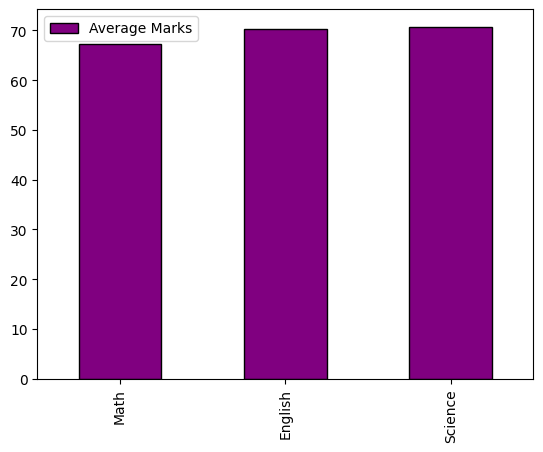

In [190]:
df = pd.DataFrame([data['math_marks'].mean(), data['science_marks'].mean(), data['english_marks'].mean()],index=['Math','Science','English'],columns=['Average Marks'])
df.sort_values('Average Marks').plot(kind='bar', color=['purple', 'orange', 'cyan'], edgecolor='black')